In [17]:
# import statements
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import time
import anndata as ad
import scanpy as sc
from tqdm import tqdm
import plotly.graph_objects as go
import scipy.sparse as sp
import io
import base64

In [75]:
# define functions

def plot_coexpressed_genes(goi, coexpression_matrix):
    print("plot_coexpressed_genes function entered.")

    coexpressed_genes = coexpression_matrix[goi].drop(goi)

    print("coexpressed genes found. plotting.")

    fig, ax = plt.subplots()
    top_10 = coexpressed_genes.sort_values(ascending=False)[:10]

    ax.barh(top_10.index, top_10.to_list())
    ax.set_title(f"{goi} Coexpressed Genes")

    plt.show()


def plot_pie(cell_info, variable):
    print("plot_pie function entered.")
    fig, ax = plt.subplots()

    class_distribution = cell_info[variable].value_counts()
    ax.pie(class_distribution.to_list(), labels=class_distribution.index, autopct="%1.1f%%")

    plt.show()


def update_visualization(goi, dataset):
    start = time.time()

    print(f"gene and dataset received.")
    
    cells = get_cells(dataset)
    em = get_em(dataset)
    goi_idx = get_gene_to_idx(goi, dataset)
    
    goi_rows = em['presence'][:, goi_idx].nonzero()[0]
    goi_cells = em['obs_names'].loc[goi_rows]['cell_label']
    cell_info = cells[cells.index.isin(goi_cells)]

    coexp_path = plot_coexpressed_genes(goi, em['coexpression'])
    class_path = plot_pie(cell_info, "class")
    subclass_path = plot_pie(cell_info, "subclass")
    supertype_path = plot_pie(cell_info, "supertype")

    finish = time.time()
    print(f"done plotting in {finish - start} seconds.")

In [74]:
# define cache

em_cache = {}
cells_cache = {}
gene_to_idx = {}


def get_em(dataset):
    if dataset not in em_cache:
        coexp = pd.read_parquet(f'data/coexp/{dataset}-coexp.parquet')
        presence = sp.load_npz(f'data/presence/{dataset}-presence.npz')
        obs_names = pd.read_parquet(f'data/obs/{dataset}-obs.parquet')
        gene_symbols = pd.read_parquet(f'data/var/{dataset}-var.parquet')['gene_symbol']

        em_cache[dataset] = {'coexpression': coexp, 'presence': presence, 'obs_names': obs_names}
        gene_to_idx[dataset] = {symbol: i for i, symbol in enumerate(gene_symbols)}
    return em_cache[dataset]


def get_cells(dataset):
    if dataset not in cells_cache:
        print(f"loading {dataset} into cache...")
        cells_path = Path(f"data/cells/{dataset}/{dataset}-cells.parquet")
        cells_cache[dataset] = pd.read_parquet(
            cells_path,
            columns=["class", "subclass", "supertype"],
            engine="pyarrow",
        )
    return cells_cache[dataset]


def get_gene_to_idx(goi, dataset):
    return gene_to_idx[dataset][goi]


def _clear_cache():
    em_cache = {}
    cells_cache = {}
    gene_to_idx = {}

In [76]:
dataset = 'Zhuang-ABCA-1' # Zhuang-ABCA-1/2/3/4
goi = 'Htr7' # gene of interest
min_transcription = 1000 # will only look at cells with minimum transcriptions or more

gene and dataset received.
loading Zhuang-ABCA-1 into cache...
plot_coexpressed_genes function entered.
coexpressed genes found. plotting.


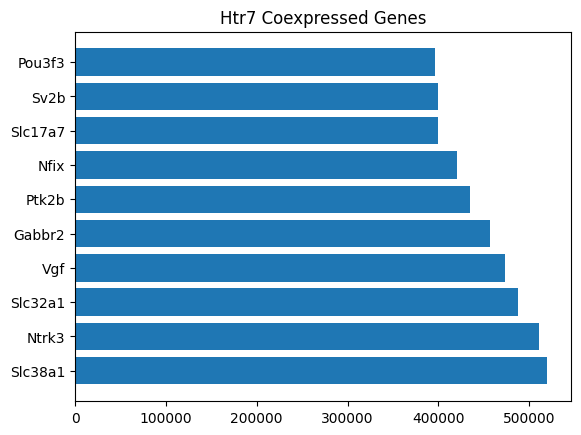

plot_pie function entered.


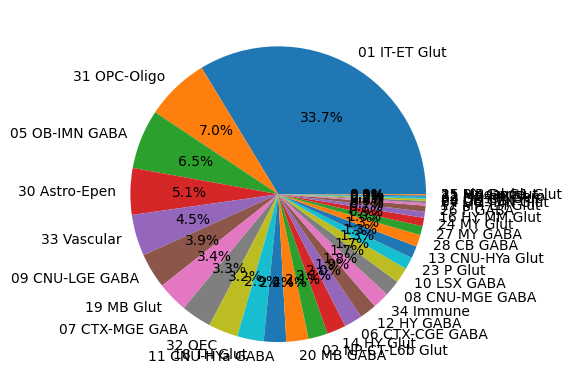

plot_pie function entered.


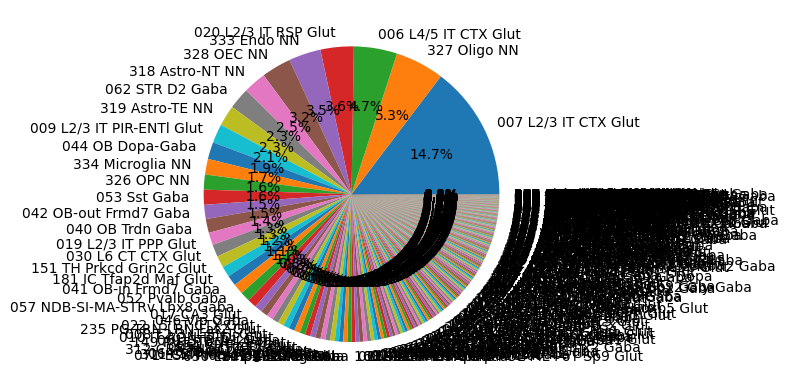

plot_pie function entered.


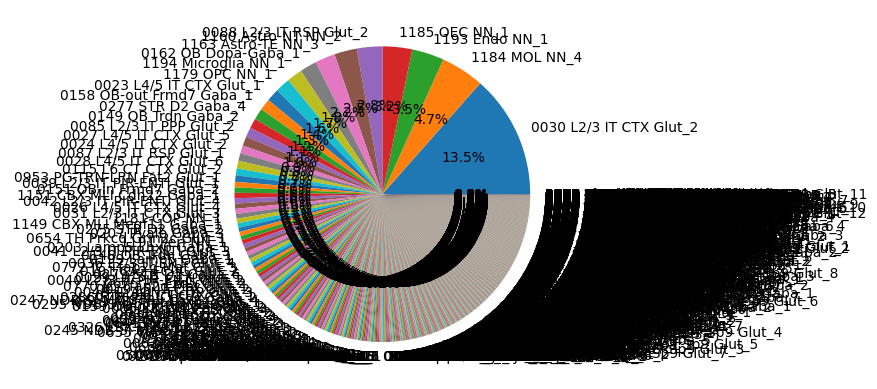

done plotting in 27.34297800064087 seconds.


In [77]:
update_visualization(goi, dataset)